# TABLAS CATEGORICAS

In [ ]:
import sys, os, duckdb
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

categoricas = [
    ('estado', 'id_clave_ent', 'region'),
    ('estado', 'id_clave_ent', 'estado'),
    ('vegetacion', 'id_vegetacion', 'regimen_del_fuego'),
    ('vegetacion', 'id_vegetacion', 'tipo_de_vegetacion'),
    ('causa', 'id_causa', 'causa'),
    ('causa', 'id_causa', 'causa_especifica'),
    ('municipios', 'id_cvegeo', 'nombre_municipio'),
    ('incendios', 'id_clave_inc', 'tipo_de_incendio'),
    ('danos', 'id_clave_inc', 'tamanio'),
    ('demografia', 'id_cvegeo', 'sexo'),
    ('diccionario', 'id_variable', 'fuente'),
    ('diccionario', 'id_variable', 'nombre_completo'),
    ('diccionario', 'id_variable', 'unidad_de_medida'),
]

forense_sql = """
    SELECT
        '{tabla}' AS origen,
        CAST({col_id} AS VARCHAR) AS id_registro,
        {col_texto} AS texto,
        LENGTH({col_texto}) <> LENGTH(TRIM({col_texto})) AS espacios_extremos,
        {col_texto} <> LOWER({col_texto}) AS mayusculas,
        regexp_matches({col_texto}, '[áéíóúüñÁÉÍÓÚÜÑ]') AS acentos,
        {col_texto} LIKE '%  %' AS dobles_espacios,
        regexp_matches({col_texto}, '[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ .,()/-]') AS caracteres_extranos
    FROM working.{tabla}
    WHERE {col_texto} IS NOT NULL
"""

# Recolectamos todas las filas sucias en un DataFrame
partes = []
for tabla, col_id, col_texto in categoricas:
    query = forense_sql.format(tabla=tabla, col_id=col_id, col_texto=col_texto)
    df_temp = con.execute(query).df()
    # Fundimos los indicadores booleanos en una sola columna "tipo_defecto"
    df_temp = df_temp.melt(
        id_vars=['origen', 'id_registro', 'texto'],
        var_name='tipo_defecto',
        value_name='presente'
    )
    # Solo conservamos los casos donde el defecto está presente
    df_temp = df_temp[df_temp['presente'] == True].drop(columns='presente')
    partes.append(df_temp)

if partes:
    df_todos = pd.concat(partes, ignore_index=True)
    
    # --- RESUMEN AGRUPADO ---
    print("=== RESUMEN DE DEFECTOS POR TABLA Y TIPO ===")
    resumen = df_todos.groupby(['origen', 'tipo_defecto']).size().reset_index(name='conteo')
    display(resumen.sort_values(['conteo'], ascending=False))
    
    # --- MUESTRA ALEATORIA PARA INSPECCIÓN ---
    print("\n=== MUESTRA DE 30 CELDAS SUCIAS ===")
    muestra = df_todos.sample(min(30, len(df_todos)), random_state=42).drop_duplicates(subset=['origen','id_registro','texto'])
    display(muestra[['origen', 'id_registro', 'texto', 'tipo_defecto']])
else:
    print("¡Ningún defecto encontrado!")
    
con.close()

=== RESUMEN DE DEFECTOS POR TABLA Y TIPO ===


,origen,tipo_defecto,conteo
5,danos,caracteres_extranos,12703
6,danos,mayusculas,12703
4,danos,acentos,12703
13,incendios,mayusculas,12652
7,demografia,mayusculas,2750
9,diccionario,mayusculas,372
15,municipios,mayusculas,220
3,causa,mayusculas,108
8,diccionario,caracteres_extranos,103
19,vegetacion,mayusculas,82



=== MUESTRA DE 30 CELDAS SUCIAS ===


,origen,id_registro,texto,tipo_defecto
46065,danos,22-15-0897,51 a 100 Hectáreas,caracteres_extranos
6478,incendios,23-15-0061,Superficial,mayusculas
31123,danos,18-15-0771,0 a 5 Hectáreas,acentos
17462,danos,22-15-0514,0 a 5 Hectáreas,mayusculas
38424,danos,25-15-0040,06 a 10 Hectáreas,acentos
33860,danos,16-15-0333,0 a 5 Hectáreas,acentos
24050,danos,24-15-0791,21 a 50 Hectáreas,mayusculas
34205,danos,18-15-0129,0 a 5 Hectáreas,acentos
52687,demografia,15007,HOMBRES,mayusculas
15249,danos,18-15-1107,0 a 5 Hectáreas,mayusculas


In [8]:
# Celda de visualización de defectos encontrados
import plotly.express as px

# Asegurarnos de que df_todos existe (viene de la celda anterior)
if 'df_todos' in locals() and not df_todos.empty:
    # Agrupamos para el gráfico
    df_plot = df_todos.groupby(['origen', 'tipo_defecto']).size().reset_index(name='conteo')
    
    # Gráfico de barras apiladas
    fig = px.bar(df_plot, 
                 x='origen', 
                 y='conteo', 
                 color='tipo_defecto',
                 title='Defectos detectados por tabla y tipo',
                 labels={'conteo': 'Número de celdas sucias', 'origen': 'Tabla'},
                 barmode='stack')
    fig.show()
    
    # También podemos mostrar un resumen general de defectos totales por tipo
    fig2 = px.bar(df_plot.groupby('tipo_defecto', as_index=False)['conteo'].sum(),
                  x='tipo_defecto', y='conteo',
                  title='Total de defectos por tipo',
                  labels={'conteo': 'Número total de celdas', 'tipo_defecto': 'Tipo de defecto'})
    fig2.show()
else:
    print("Primero ejecuta la celda de diagnóstico forense para generar df_todos.")

In [26]:
import sys, os, duckdb
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

# 1. NULOS EN COLUMNAS CATEGÓRICAS (las que limpiamos)
categoricas = {
    'estado': ['region', 'estado'],
    'vegetacion': ['regimen_del_fuego', 'tipo_de_vegetacion'],
    'causa': ['causa', 'causa_especifica'],
    'municipios': ['nombre_municipio', 'id_cvegeo'],
    'incendios': ['tipo_de_incendio'],
    'danos': ['tamanio'],
    'demografia': ['sexo'],
    'diccionario': ['fuente', 'nombre_completo', 'unidad_de_medida']
}

print("=== NULOS EN COLUMNAS CATEGÓRICAS (WORKING) ===")
for tabla, columnas in categoricas.items():
    for col in columnas:
        nulos = con.execute(f"SELECT COUNT(*) FROM working.{tabla} WHERE {col} IS NULL").fetchone()[0]
        if nulos > 0:
            print(f"   {tabla}.{col}: {nulos} nulos")

# 2. DUPLICADOS TRAS NORMALIZACIÓN (catalogos)
print("\n=== POSIBLES DUPLICADOS EN CATÁLOGOS ===")
# Vegetación
dup_veg = con.execute("""
    SELECT regimen_del_fuego, tipo_de_vegetacion, COUNT(*) AS n
    FROM working.vegetacion
    GROUP BY regimen_del_fuego, tipo_de_vegetacion
    HAVING COUNT(*) > 1
""").df()
if not dup_veg.empty:
    print("Duplicados en vegetación:")
    display(dup_veg)

# Causa
dup_causa = con.execute("""
    SELECT causa, causa_especifica, COUNT(*) AS n
    FROM working.causa
    GROUP BY causa, causa_especifica
    HAVING COUNT(*) > 1
""").df()
if not dup_causa.empty:
    print("Duplicados en causa:")
    display(dup_causa)

# Municipios (por id_cvegeo)
dup_mun = con.execute("""
    SELECT id_cvegeo, COUNT(*) AS n
    FROM working.municipios
    GROUP BY id_cvegeo
    HAVING COUNT(*) > 1
""").df()
if not dup_mun.empty:
    print("Duplicados en municipios:")
    display(dup_mun)

con.close()

=== NULOS EN COLUMNAS CATEGÓRICAS (WORKING) ===

=== POSIBLES DUPLICADOS EN CATÁLOGOS ===


# Limpiar en todas las atributos todos los defectos 

* acentos
* caracteres extraños a excepcion de la entidad diccionarios especificamente en la variable de unidad de medida es normal que venga asi entonces esa no se tocara 
* espacios extremos aunque solo se encontraron 2 errores pero quien sabe en donde este
* mayusculas 

cualquier carácter que NO sea una letra (con o sin acento), espacio, punto, coma, paréntesis, diagonal o guion normal, es marcado como extraño.

LA FUNCION QUE SE UTILIZARA PARA APLICAR ESA LIMPIEZA SERA:


def limpiar_textos_categoricos(con):
    """
    Aplica normalización a todas las columnas de texto descriptivas de los catálogos
    e incendios, excepto 'unidad_de_medida' en diccionario.
    Reglas:
      - minúsculas
      - elimina acentos
      - sustituye saltos de línea, tabulaciones y retornos por espacio
      - elimina caracteres extraños (solo deja letras, números, espacios, punto, coma,
        paréntesis, guion, diagonal y apóstrofe)
      - recorta espacios extremos
      - sustituye múltiples espacios por uno solo
    """
    # Columnas que se van a limpiar (todas las que inspeccionamos antes)
    columnas_a_limpiar = [
        ('estado', 'region'),
        ('estado', 'estado'),
        ('vegetacion', 'regimen_del_fuego'),
        ('vegetacion', 'tipo_de_vegetacion'),
        ('causa', 'causa'),
        ('causa', 'causa_especifica'),
        ('municipios', 'nombre_municipio'),
        ('incendios', 'tipo_de_incendio'),
        ('danos', 'tamanio'),
        ('demografia', 'sexo'),
        ('diccionario', 'fuente'),
        ('diccionario', 'nombre_completo'),
        # ('diccionario', 'unidad_de_medida')  # Excluida porque contiene símbolos válidos
    ]

    for tabla, columna in columnas_a_limpiar:
        # Construir expresión SQL que aplica todas las transformaciones de una vez
        # Se usa REPLACE para caracteres de control y luego REGEXP_REPLACE para eliminar
        # lo que no esté en la lista blanca.
        print(f"Limpiando {tabla}.{columna} ...")
        con.execute(f"""
            UPDATE working.{tabla}
            SET "{columna}" = REGEXP_REPLACE(
                                REGEXP_REPLACE(
                                    TRIM(
                                        LOWER(
                                            REPLACE(REPLACE(REPLACE(
                                                REGEXP_REPLACE("{columna}", '[áÁ]', 'a', 'g'),
                                                'éÉ', 'e'),
                                                'íÍ', 'i'),
                                                'óÓ', 'o'),
                                            'úÚüÜ', 'u'),
                                        'ñÑ', 'n'),
                                    '  ', ' '),                            -- dobles espacios
                                '[^a-z0-9 .,()/''-]', '', 'g')          -- caracteres extraños
            WHERE "{columna}" IS NOT NULL
        """)
    print("Limpieza completada.")

# VARIABLES NUMERICAS

# CORREGIR VALORES IMPOSIBLES E ILOGICOS

## ENTIDAD INCENDIOS

=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS E IMPOSIBLES ===

1. Año vs Fecha Inicio: 1 registros con error.
   -> Muestra de registros a corregir:


,id_clave_inc,id_cvegeo,id_causa,id_vegetacion,latitud,longitud,fecha_inicio,tipo_de_incendio,anio
0,21-15-0001,15009,1,39,19.112009,-98.64048,2020-12-31,Superficial,2021


------------------------------------------------------------
2. Latitud fuera de rango [18.7, 20.3]: 169 registros con error.
   -> Muestra de registros a corregir:


,id_clave_inc,id_cvegeo,id_causa,id_vegetacion,latitud,longitud,fecha_inicio,tipo_de_incendio,anio
0,15-15-0188,15048,33,21,0.0,0.0,2015-03-05,Superficial,2015
1,15-15-0190,15118,24,15,0.0,0.0,2015-03-05,Superficial,2015
2,16-15-0410,15018,1,28,0.0,0.0,2016-03-13,Superficial,2016
3,16-15-0826,15048,8,28,0.0,0.0,2016-04-06,Superficial,2016
4,16-15-1100,15086,24,28,0.0,0.0,2016-04-17,Superficial,2016


------------------------------------------------------------
3. Longitud fuera de rango [-100.6, -98.4]: 110 registros con error.
   -> Muestra de registros a corregir:


,id_clave_inc,id_cvegeo,id_causa,id_vegetacion,latitud,longitud,fecha_inicio,tipo_de_incendio,anio
0,15-15-0188,15048,33,21,0.000000,0.000000,2015-03-05,Superficial,2015
1,15-15-0190,15118,24,15,0.000000,0.000000,2015-03-05,Superficial,2015
2,16-15-0410,15018,1,28,0.000000,0.000000,2016-03-13,Superficial,2016
3,16-15-0633,15063,8,31,18.990473,-92.367889,2016-03-29,Superficial,2016
4,16-15-0826,15048,8,28,0.000000,0.000000,2016-04-06,Superficial,2016


------------------------------------------------------------
4. Fecha de inicio en el futuro: 0 registros con error.


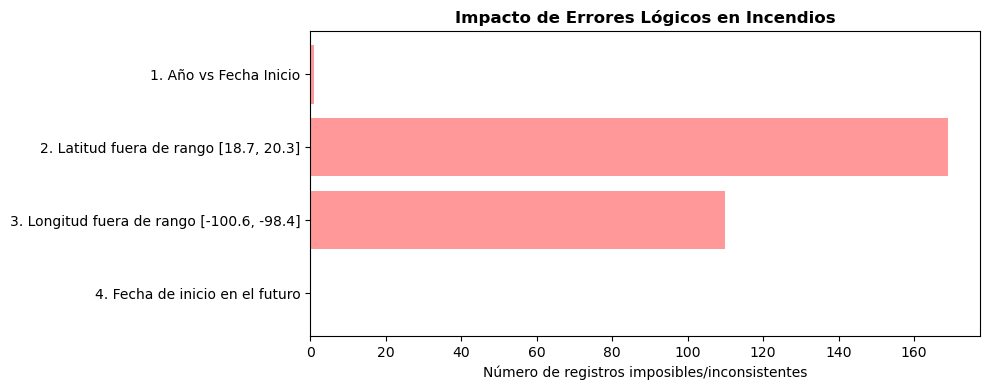

In [ ]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS E IMPOSIBLES ===\n")

reglas_validacion = {
    "1. Año vs Fecha Inicio": "anio <> EXTRACT(YEAR FROM fecha_inicio)",
    "2. Latitud fuera de rango [18.7, 20.3]": "latitud NOT BETWEEN 18.7 AND 20.3",
    "3. Longitud fuera de rango [-100.6, -98.4]": "longitud NOT BETWEEN -100.6 AND -98.4",
    "4. Fecha de inicio en el futuro": "fecha_inicio > CURRENT_DATE"
}

resultados_resumen = []

# Evaluación de reglas
for nombre_regla, condicion in reglas_validacion.items():
    q = f"SELECT * FROM working.incendios WHERE {condicion}"
    df_errores = con.execute(q).df()
    
    total_errores = len(df_errores)
    resultados_resumen.append({"Regla": nombre_regla, "Violaciones": total_errores})
    
    print(f"{nombre_regla}: {total_errores} registros con error.")
    
    # Mostrar tabla solo para los casos ilógicos encontrados
    if total_errores > 0:
        print(f"   -> Muestra de registros a corregir:")
        display(df_errores.head(5))
        print("-" * 60)

# Resumen visual (solo para esta fase)
df_resumen = pd.DataFrame(resultados_resumen)

plt.figure(figsize=(10, 4))
plt.barh(df_resumen['Regla'], df_resumen['Violaciones'], color=['#ff9999' if v > 0 else '#99ff99' for v in df_resumen['Violaciones']])
plt.title('Impacto de Errores Lógicos en Incendios', fontweight='bold')
plt.xlabel('Número de registros imposibles/inconsistentes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## ENTIDAD OPERACIONES

=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (OPERACIONES) ===

6. Término antes de inicio: 0 registros con error.
7. Llegada antes de detección: 136 registros con error.
   -> Muestra de registros a investigar:


,id_clave_inc,fecha_termino,hora_deteccion,hora_llegada,duracion_hhmm,duracion_dias
0,15-15-0350,2015-04-18,01:12:00,01:00:00,0 days 02:40:00,<NA>
1,16-15-0539,2016-03-26,00:50:00,00:25:00,0 days 03:30:00,<NA>
2,17-15-1061,2017-04-20,00:10:00,00:05:00,0 days 00:40:00,<NA>
3,18-15-0536,2018-03-20,00:10:00,00:05:00,0 days 03:05:00,<NA>
4,18-15-0557,2018-03-21,00:05:00,00:02:00,0 days 01:04:00,<NA>


-----------------------------------------------------------------
8. Duración en días negativa: 0 registros con error.
9. Incongruencia días vs hh:mm (>1h): 0 registros con error.
10. Término en el futuro: 0 registros con error.

=== GRÁFICA DE DIAGNÓSTICO ===


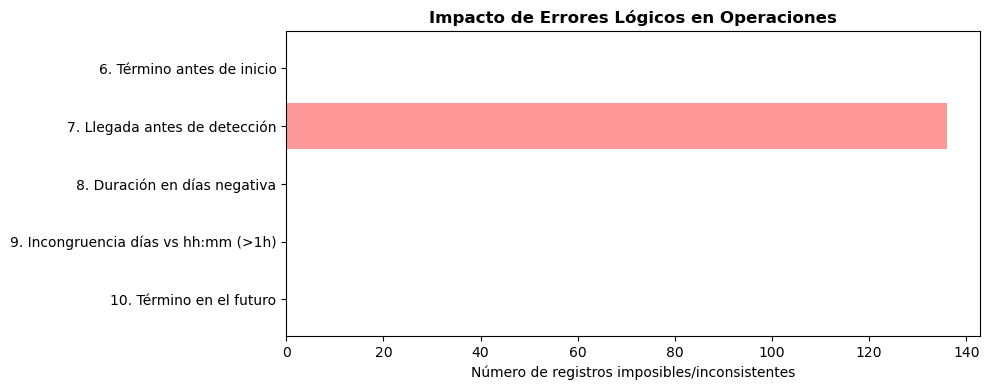

In [4]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (OPERACIONES) ===\n")

# Definimos las reglas con su consulta SQL completa. 
# Esto nos permite hacer JOINs en la Regla 6 sin ensuciar la lógica general.
reglas_operaciones = {
    "6. Término antes de inicio": """
        SELECT o.id_clave_inc, i.fecha_inicio, o.fecha_termino
        FROM working.operaciones o
        JOIN working.incendios i ON o.id_clave_inc = i.id_clave_inc
        WHERE o.fecha_termino < i.fecha_inicio
    """,
    "7. Llegada antes de detección": """
        SELECT * FROM working.operaciones
        WHERE hora_llegada < hora_deteccion
    """,
    "8. Duración en días negativa": """
        SELECT * FROM working.operaciones
        WHERE duracion_dias < 0
    """,
    "9. Incongruencia días vs hh:mm (>1h)": """
        SELECT * FROM working.operaciones
        WHERE duracion_dias IS NOT NULL
          AND duracion_hhmm IS NOT NULL
          AND ABS(duracion_dias * 1440 - (EXTRACT(HOUR FROM duracion_hhmm)*60 + EXTRACT(MINUTE FROM duracion_hhmm))) > 60
    """,
    "10. Término en el futuro": """
        SELECT * FROM working.operaciones
        WHERE fecha_termino > CURRENT_DATE
    """
}

resultados_ops = []

# Evaluación automatizada de las reglas
for nombre_regla, query in reglas_operaciones.items():
    # Ejecutamos la consulta y la convertimos directo a DataFrame
    df_errores = con.execute(query).df()
    
    total_errores = len(df_errores)
    resultados_ops.append({"Regla": nombre_regla, "Violaciones": total_errores})
    
    print(f"{nombre_regla}: {total_errores} registros con error.")
    
    # Si hay errores, mostramos la tabla de evidencia para poder corregirlos
    if total_errores > 0:
        print(f"   -> Muestra de registros a investigar:")
        display(df_errores.head(5))
        print("-" * 65)

# ============================================================
# RESUMEN VISUAL (GRÁFICA)
# ============================================================
print("\n=== GRÁFICA DE DIAGNÓSTICO ===")

df_resumen = pd.DataFrame(resultados_ops)

plt.figure(figsize=(10, 4))
# Pintamos de rojo si hay violaciones (>0) y verde si la regla está limpia
colores = ['#ff9999' if v > 0 else '#99ff99' for v in df_resumen['Violaciones']]

plt.barh(df_resumen['Regla'], df_resumen['Violaciones'], color=colores)
plt.title('Impacto de Errores Lógicos en Operaciones', fontweight='bold')
plt.xlabel('Número de registros imposibles/inconsistentes')

# Invertimos el eje Y para que la regla 6 quede arriba y la 10 abajo
plt.gca().invert_yaxis()

# Ajustamos el layout para que los textos largos no se corten
plt.tight_layout()
plt.show()

#### Por ahora se convierten a NULL

## ENTIDAD DAÑOS

=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (DAÑOS) ===

11. Hojarasca < 0: 0 registros con error.
11. Arbustivo < 0: 0 registros con error.
11. Herbaceo < 0: 0 registros con error.
11. Arbolado_adulto < 0: 0 registros con error.
11. Renuevo < 0: 0 registros con error.
12. Incongruencia Suma vs Categoría Tamaño: 0 registros con error.

=== GRÁFICA DE DIAGNÓSTICO: DAÑOS ===


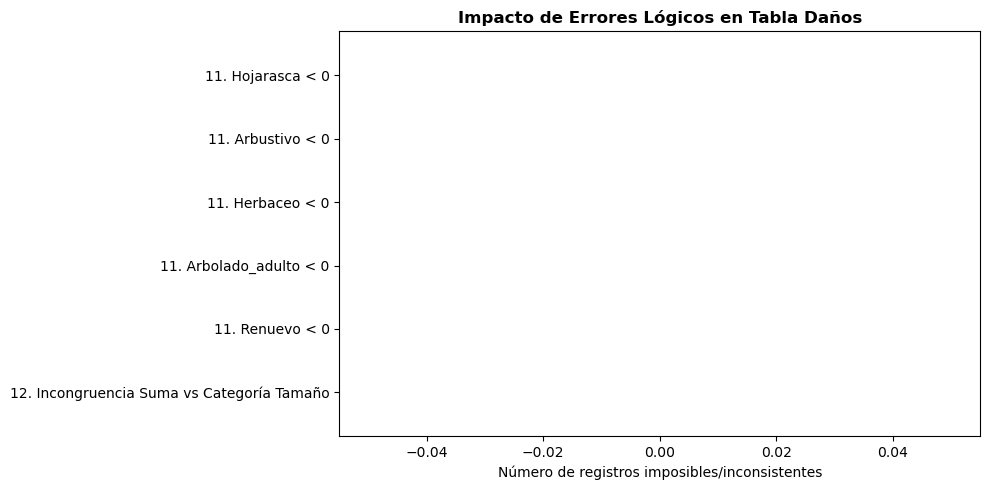

In [2]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (DAÑOS) ===\n")

reglas_danos = {}
columnas_cobertura = ['hojarasca', 'arbustivo', 'herbaceo', 'arbolado_adulto', 'renuevo']

# 11. Generamos las reglas de negativos dinámicamente
for col in columnas_cobertura:
    reglas_danos[f"11. {col.capitalize()} < 0"] = f"""
        SELECT id_clave_inc, {col} 
        FROM working.danos 
        WHERE {col} < 0
    """

# 12. Incongruencia Suma vs Categoría Tamaño
# Se usa un CTE (WITH) para calcular la suma una sola vez y evaluar los límites de forma limpia.
# Se incluye '06 a 10 Hectáreas' en la misma regla que '6 a 10 Hectáreas'.

# 12. Incongruencia Suma vs Categoría Tamaño (CON TOLERANCIA)
reglas_danos["12. Incongruencia Suma vs Categoría Tamaño"] = """
    WITH calculo_sumas AS (
        SELECT 
            id_clave_inc, 
            tamanio AS categoria_registrada,
            (COALESCE(hojarasca, 0) + COALESCE(arbustivo, 0) + 
             COALESCE(herbaceo, 0) + COALESCE(arbolado_adulto, 0) + 
             COALESCE(renuevo, 0)) AS suma
        FROM working.danos
    )
    SELECT * FROM calculo_sumas
    WHERE 
        -- Aplicamos un margen de tolerancia de 1 hectárea hacia arriba y hacia abajo
        (categoria_registrada = '0 a 5 Hectáreas' AND suma > 6) 
        OR (categoria_registrada IN ('6 a 10 Hectáreas', '06 a 10 Hectáreas') AND (suma < 5 OR suma > 11)) 
        OR (categoria_registrada = '11 a 20 Hectáreas' AND (suma < 10 OR suma > 21)) 
        OR (categoria_registrada = '21 a 50 Hectáreas' AND (suma < 20 OR suma > 51)) 
        OR (categoria_registrada = '51 a 100 Hectáreas' AND (suma < 50 OR suma > 101)) 
        OR (categoria_registrada = 'Mayor a 100 Hectáreas' AND suma <= 99)
"""

resultados_danos = []

# Evaluación automatizada
for nombre_regla, query in reglas_danos.items():
    df_errores = con.execute(query).df()
    
    total_errores = len(df_errores)
    resultados_danos.append({"Regla": nombre_regla, "Violaciones": total_errores})
    
    print(f"{nombre_regla}: {total_errores} registros con error.")
    
    if total_errores > 0:
        print(f"   -> Muestra de registros a corregir:")
        display(df_errores.head(5))
        print("-" * 65)

# ============================================================
# RESUMEN VISUAL (GRÁFICA)
# ============================================================
print("\n=== GRÁFICA DE DIAGNÓSTICO: DAÑOS ===")

df_resumen = pd.DataFrame(resultados_danos)

plt.figure(figsize=(10, 5))
colores = ['#ff9999' if v > 0 else '#99ff99' for v in df_resumen['Violaciones']]

plt.barh(df_resumen['Regla'], df_resumen['Violaciones'], color=colores)
plt.title('Impacto de Errores Lógicos en Tabla Daños', fontweight='bold')
plt.xlabel('Número de registros imposibles/inconsistentes')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

No se realiza NADA 

## ENTIDAD DEMOGRAFIA

=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (DEMOGRAFÍA) ===

13. Población total negativa: 0 registros con error.
14. Suma de rangos difiere > 5% de pob_total: 0 registros con error.

=== GRÁFICA DE DIAGNÓSTICO: DEMOGRAFÍA ===


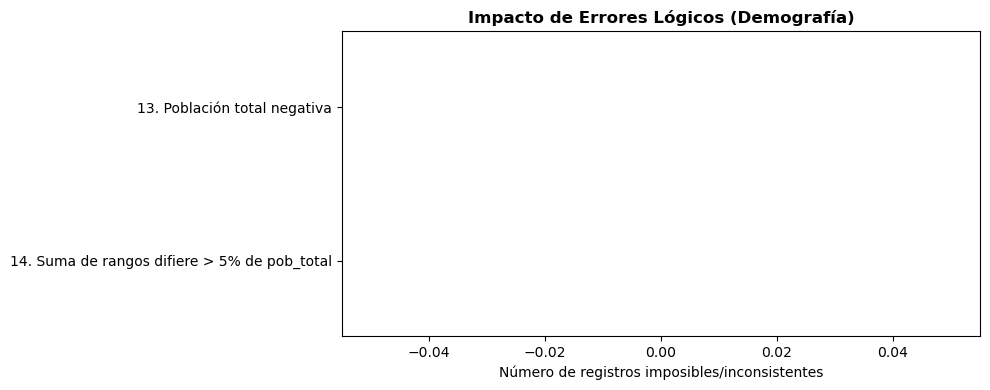

In [4]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (DEMOGRAFÍA) ===\n")

reglas_demografia = {
    "13. Población total negativa": """
        SELECT id_cvegeo, anio, sexo, pob_total 
        FROM working.demografia 
        WHERE pob_total < 0
    """,
    "14. Suma de rangos difiere > 5% de pob_total": """
        WITH calculo_poblacion AS (
            SELECT 
                id_cvegeo, anio, sexo, pob_total,
                (COALESCE(r_00_04, 0) + COALESCE(r_05_09, 0) + COALESCE(r_10_14, 0) + 
                 COALESCE(r_15_19, 0) + COALESCE(r_20_24, 0) + COALESCE(r_25_29, 0) + 
                 COALESCE(r_30_34, 0) + COALESCE(r_35_39, 0) + COALESCE(r_40_44, 0) + 
                 COALESCE(r_45_49, 0) + COALESCE(r_50_54, 0) + COALESCE(r_55_59, 0) + 
                 COALESCE(r_60_64, 0) + COALESCE(r_65_69, 0) + COALESCE(r_70_74, 0) + 
                 COALESCE(r_75_79, 0) + COALESCE(r_80_84, 0) + COALESCE(r_85_mm, 0)) AS suma_rangos
            FROM working.demografia
        )
        SELECT * FROM calculo_poblacion
        WHERE ABS(pob_total - suma_rangos) > (pob_total * 0.05)
    """
}

resultados_demo = []

# Evaluación automatizada de las reglas estrictas
for nombre_regla, query in reglas_demografia.items():
    df_errores = con.execute(query).df()
    
    total_errores = len(df_errores)
    resultados_demo.append({"Regla": nombre_regla, "Violaciones": total_errores})
    
    print(f"{nombre_regla}: {total_errores} registros con error.")
    
    if total_errores > 0:
        print(f"   -> Muestra de registros a investigar:")
        display(df_errores.head(5))
        print("-" * 65)

# ============================================================
# RESUMEN VISUAL (GRÁFICA)
# ============================================================
print("\n=== GRÁFICA DE DIAGNÓSTICO: DEMOGRAFÍA ===")

df_resumen = pd.DataFrame(resultados_demo)

plt.figure(figsize=(10, 4))
colores = ['#ff9999' if v > 0 else '#99ff99' for v in df_resumen['Violaciones']]

plt.barh(df_resumen['Regla'], df_resumen['Violaciones'], color=colores)
plt.title('Impacto de Errores Lógicos (Demografía)', fontweight='bold')
plt.xlabel('Número de registros imposibles/inconsistentes')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### No se realiza nada 

## ENTIDAD CLIMA

16. Análisis de Ruido (-999.0) en formato EAV basado en porcentajes por variable:
-> Lista de variables afectadas (ordenadas por porcentaje de pérdida):


,id_variable,total_esperado_variable,total_ruido,porcentaje_perdido
0,CLOUD_BT_MAX,127030,127030.0,100.00
1,CLOUD_TT_MAX,127040,127040.0,100.00
2,IMERG_PRECLIQUID_PROB,127030,127030.0,100.00
3,GWM_HEIGHT,127030,127030.0,100.00
4,SZA,127030,127030.0,100.00
5,CLOUD_TT,127040,127040.0,100.00
6,RZMC_PRCNTL,127030,127030.0,100.00
7,GWM_HEIGHT_ANOMALY,127030,127030.0,100.00
8,IMERG_PRECTOT,127030,127030.0,100.00
9,IMERG_PRECTOT_COUNT,127030,127030.0,100.00



 ELIMINAR: 23 VARIABLES A ELIMINAR (>40% ruido)


,id_variable,total_esperado_variable,total_ruido,porcentaje_perdido
0,CLOUD_BT_MAX,127030,127030.0,100.0
1,CLOUD_TT_MAX,127040,127040.0,100.0
2,IMERG_PRECLIQUID_PROB,127030,127030.0,100.0
3,GWM_HEIGHT,127030,127030.0,100.0
4,SZA,127030,127030.0,100.0
5,CLOUD_TT,127040,127040.0,100.0
6,RZMC_PRCNTL,127030,127030.0,100.0
7,GWM_HEIGHT_ANOMALY,127030,127030.0,100.0
8,IMERG_PRECTOT,127030,127030.0,100.0
9,IMERG_PRECTOT_COUNT,127030,127030.0,100.0


----------------------------------------------------------------------

=== GRÁFICA DE DIAGNÓSTICO: IMPACTO DEL RUIDO ===


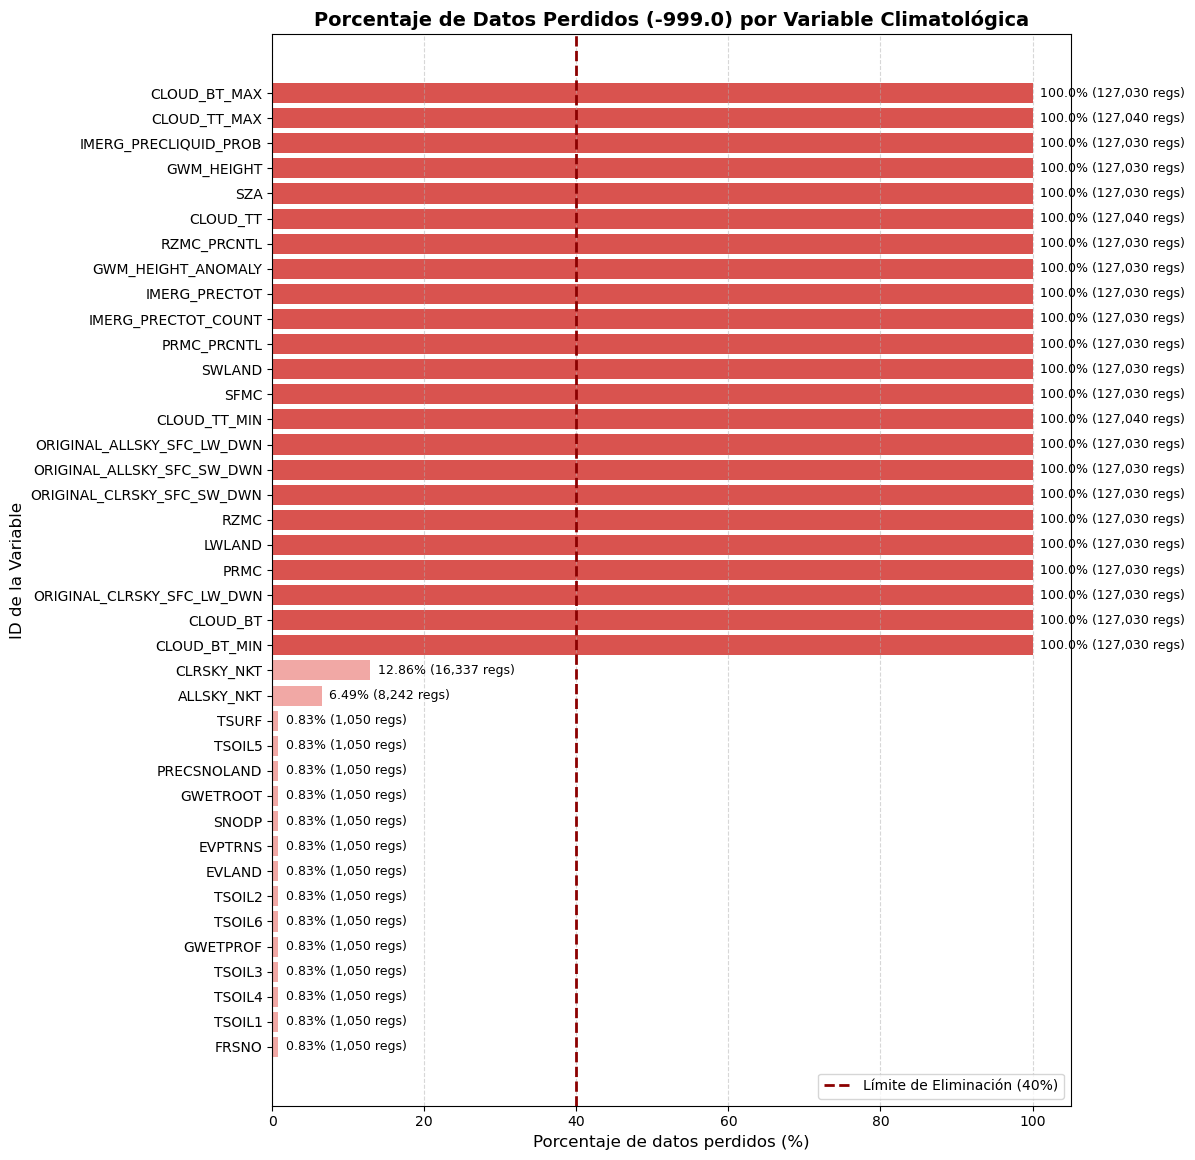

In [ ]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("16. Análisis de Ruido (-999.0) en formato EAV basado en porcentajes por variable:")

# Consulta SQL con el cálculo porcentual exacto sobre el universo de cada variable
q_porcentaje = """
    SELECT 
        id_variable, 
        COUNT(*) AS total_esperado_variable,
        SUM(CASE WHEN resultado_numerico = -999.0 THEN 1 ELSE 0 END) AS total_ruido,
        ROUND((SUM(CASE WHEN resultado_numerico = -999.0 THEN 1 ELSE 0 END) * 100.0) / COUNT(*), 2) AS porcentaje_perdido
    FROM working.climatologia
    GROUP BY id_variable
    HAVING SUM(CASE WHEN resultado_numerico = -999.0 THEN 1 ELSE 0 END) > 0
    ORDER BY porcentaje_perdido DESC
"""

# DuckDB procesa los millones de registros velozmente
df_ruido = con.execute(q_porcentaje).df()

if not df_ruido.empty:
    print("-> Lista de variables afectadas (ordenadas por porcentaje de pérdida):")
    # Mostramos la tabla completa sin que Jupyter la recorte
    with pd.option_context('display.max_rows', None):
        display(df_ruido)
        
    # Extraemos las condenadas a eliminación (>40%)
    condenadas = df_ruido[df_ruido['porcentaje_perdido'] > 40.0]
    
    print("\n" + "="*70)
    print(f" ELIMINAR: {len(condenadas)} VARIABLES A ELIMINAR (>40% ruido)")
    print("="*70)
    if not condenadas.empty:
        display(condenadas)
    else:
        print("Milagrosamente, ninguna variable supera el 40% de datos perdidos.")
        
print("-" * 70)

# ============================================================
# RESUMEN VISUAL (GRÁFICA DE PORCENTAJES)
# ============================================================
if not df_ruido.empty:
    print("\n=== GRÁFICA DE DIAGNÓSTICO: IMPACTO DEL RUIDO ===")
    
    # Altura dinámica: 0.3 pulgadas por variable para que siempre sea legible
    alto_grafica = max(5, len(df_ruido) * 0.3)
    
    plt.figure(figsize=(12, alto_grafica))
    
    # Colores condicionales: Rojo oscuro para >40% (eliminar), salmón claro para <40% (imputar)
    colores = ['#d9534f' if p > 40.0 else '#f1a8a5' for p in df_ruido['porcentaje_perdido']]
    
    # Graficamos usando el PORCENTAJE en el eje X, no el conteo absoluto
    plt.barh(df_ruido['id_variable'].astype(str), df_ruido['porcentaje_perdido'], color=colores)
    
    # Línea vertical del umbral crítico (40%)
    plt.axvline(x=40, color='darkred', linestyle='--', linewidth=2, label='Límite de Eliminación (40%)')
    
    plt.title('Porcentaje de Datos Perdidos (-999.0) por Variable Climatológica', fontweight='bold', fontsize=14)
    plt.xlabel('Porcentaje de datos perdidos (%)', fontsize=12)
    plt.ylabel('ID de la Variable', fontsize=12)
    
    # Invertimos el eje Y para que la variable con más errores salga hasta arriba
    plt.gca().invert_yaxis()
    
    # Límite del eje X hasta 100% para dar contexto real
    plt.xlim(0, 105)
    
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')
    
    # Textos al final de cada barra con el porcentaje y el número crudo entre paréntesis
    for index, row in df_ruido.iterrows():
        plt.text(row['porcentaje_perdido'] + 1, index, 
                 f"{row['porcentaje_perdido']}% ({int(row['total_ruido']):,} regs)", 
                 va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("\n¡Excelente! No se encontró ningún registro con valor -999.0.")

### Convertir a NULL